# 03 — Where the object sits

**Task 3:** look at how the reconstruction changes when the object is in different places — near
the middle and near the edge.

---

EIT is not like a camera, where a small object looks the same wherever it is. The current mostly
runs near the edge of the tank, so an object near an electrode has a much bigger effect on the
measurements than the same object in the middle.

This notebook moves one object from the centre outwards and watches what happens.

In [1]:
import os, sys, time, warnings
from pathlib import Path

# Find pyEIT: either installed, or via the PYEIT_PATH environment variable.
try:
    import pyeit
except ImportError:
    for folder in filter(None, [os.environ.get("PYEIT_PATH"), "../pyEIT", "./pyEIT"]):
        if (Path(folder) / "pyeit").is_dir():
            sys.path.insert(0, str(Path(folder).resolve())); break
    import pyeit

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eit_helpers as eit

eit.use_project_style()
figures = Path("figures"); figures.mkdir(exist_ok=True)
tables = Path("results"); tables.mkdir(exist_ok=True)

print(f"{eit.NUMBER_OF_ELECTRODES} electrodes, background conductivity "
      f"{eit.BACKGROUND_CONDUCTIVITY}, images {eit.IMAGE_SIZE}x{eit.IMAGE_SIZE}")

16 electrodes, background conductivity 1.0, images 64x64


In [2]:
fine_mesh, coarse_mesh = eit.build_meshes()
measurement_setup = eit.build_measurement_setup("adjacent")
OBJECT_RADIUS = 0.15
prepared = {method: eit.prepare_method(method, coarse_mesh, measurement_setup)[:2]
            for method in eit.METHODS}
print("ready")

ready


## Which parts of the tank are easy to see

First, a map of how much each part of the tank affects the measurements. Bright means a change
there shows up strongly at the electrodes; dark means it barely registers.

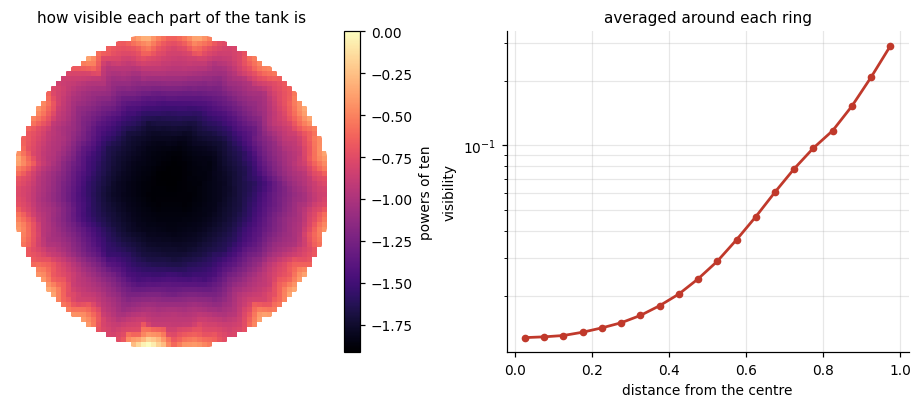

the centre is about 23x less visible than the edge


In [3]:
sensitivity = eit.sensitivity_map(coarse_mesh, measurement_setup)

figure, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
drawn = axes[0].imshow(np.log10(sensitivity), origin="lower", extent=eit.IMAGE_EXTENT,
                       cmap="magma")
axes[0].add_patch(plt.Circle((0, 0), 1.0, fill=False, lw=0.8, color="w"))
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])
for edge in axes[0].spines.values():
    edge.set_visible(False)
axes[0].set_title("how visible each part of the tank is")
figure.colorbar(drawn, ax=axes[0], fraction=0.046, pad=0.03, label="powers of ten")

pixel_positions = np.linspace(-1, 1, eit.IMAGE_SIZE)
grid_x, grid_y = np.meshgrid(pixel_positions, pixel_positions)
distance_from_centre = np.hypot(grid_x, grid_y)
ring_edges = np.linspace(0, 1, 21)
ring_centres = 0.5 * (ring_edges[:-1] + ring_edges[1:])
ring_average = np.array([np.nanmean(sensitivity[(distance_from_centre >= inner)
                                                & (distance_from_centre < outer)])
                         for inner, outer in zip(ring_edges[:-1], ring_edges[1:])])

axes[1].semilogy(ring_centres, ring_average, marker="o", ms=4, lw=1.8, color="#c0392b")
axes[1].set_xlabel("distance from the centre"); axes[1].set_ylabel("visibility")
axes[1].set_title("averaged around each ring"); axes[1].grid(alpha=0.3, which="both")
figure.savefig(figures / "03_sensitivity.png")
plt.show()

print(f"the centre is about {ring_average[-1] / ring_average[0]:.0f}x less visible than the edge")

That factor is the whole story of this notebook. Everything below follows from it.

## Moving the object out from the centre

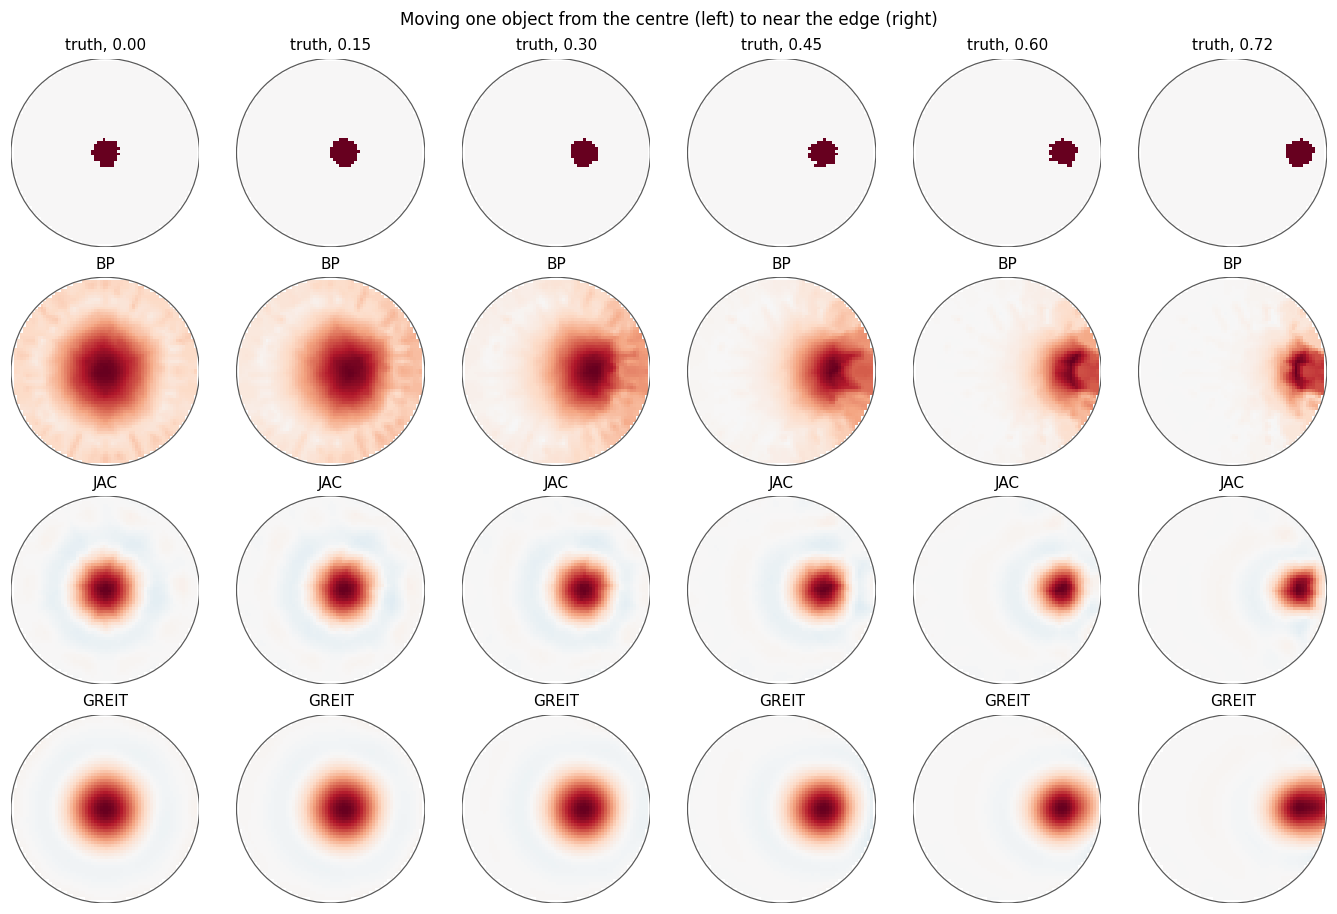

In [4]:
distances = [0.0, 0.15, 0.30, 0.45, 0.60, 0.72]

position_rows, all_data = [], {}
for distance in distances:
    tank = eit.add_objects(fine_mesh, [{"centre": [distance, 0.0],
                                        "radius": OBJECT_RADIUS, "conductivity": 2.0}])
    background_voltages, object_voltages = eit.simulate_measurements(
        fine_mesh, tank, measurement_setup)
    truth = eit.true_picture(fine_mesh, tank)
    all_data[distance] = (background_voltages, object_voltages, truth)
    signal_size = float(np.abs(np.real(object_voltages - background_voltages)).mean())

    for method in eit.METHODS:
        solver, setup_seconds = prepared[method]
        result = eit.reconstruct_image(method, coarse_mesh, measurement_setup,
                                       object_voltages, background_voltages,
                                       prepared_solver=solver)
        position_rows.append(dict(method=method, distance=distance,
                                  signal_size=signal_size,
                                  visibility=eit.contrast_to_noise(result.image, truth),
                                  **eit.score_image(truth, result.image)))
position_scores = pd.DataFrame(position_rows)
position_scores.to_csv(tables / "03_position.csv", index=False)

figure, axes = plt.subplots(len(eit.METHODS) + 1, len(distances),
                            figsize=(2.05 * len(distances), 2.05 * (len(eit.METHODS) + 1)),
                            constrained_layout=True)
for column, distance in enumerate(distances):
    _, _, truth = all_data[distance]
    eit.show_image(axes[0, column], truth, title=f"truth, {distance:.2f}")
    for row, method in enumerate(eit.METHODS, start=1):
        solver, setup_seconds = prepared[method]
        background_voltages, object_voltages, _ = all_data[distance]
        result = eit.reconstruct_image(method, coarse_mesh, measurement_setup,
                                       object_voltages, background_voltages,
                                       prepared_solver=solver)
        eit.show_image(axes[row, column], result.scaled, title=eit.METHOD_SHORT[method])
figure.suptitle("Moving one object from the centre (left) to near the edge (right)", fontsize=11)
figure.savefig(figures / "03_positions.png")
plt.show()

Even by eye: the blob in the middle is big and faint, and it tightens up as the object moves
outward. Right at the edge it starts getting squashed against the tank wall.

## The same thing as numbers

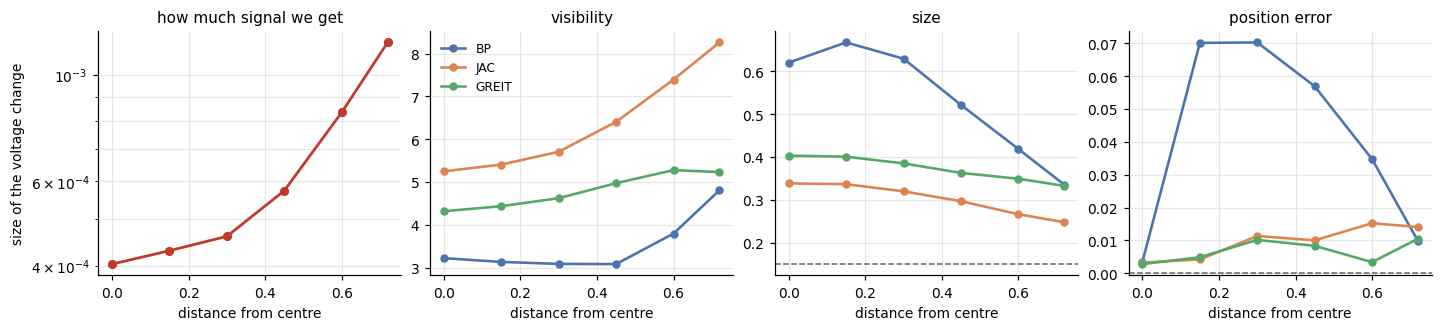

size                          visibility               \
method   back_projection gauss_newton  greit back_projection gauss_newton   
distance                                                                    
0.00               0.621        0.339  0.403           3.222        5.249   
0.15               0.668        0.337  0.401           3.134        5.408   
0.30               0.630        0.320  0.385           3.089        5.707   
0.45               0.522        0.297  0.363           3.083        6.406   
0.60               0.419        0.267  0.349           3.796        7.393   
0.72               0.335        0.248  0.333           4.807        8.261   

                 
method    greit  
distance         
0.00      4.318  
0.15      4.436  
0.30      4.623  
0.45      4.973  
0.60      5.278  
0.72      5.233

In [5]:
figure, axes = plt.subplots(1, 4, figsize=(13, 2.9), constrained_layout=True)

signal_by_distance = position_scores.groupby("distance").signal_size.first()
axes[0].semilogy(signal_by_distance.index, signal_by_distance.values,
                 marker="o", ms=5, lw=1.8, color="#c0392b")
axes[0].set_xlabel("distance from centre"); axes[0].set_ylabel("size of the voltage change")
axes[0].set_title("how much signal we get"); axes[0].grid(alpha=0.3, which="both")

for axis, column, target in zip(axes[1:], ["visibility", "size", "position_error"],
                                [None, OBJECT_RADIUS, 0.0]):
    for method in eit.METHODS:
        rows = position_scores[position_scores.method == method].sort_values("distance")
        axis.plot(rows.distance, rows[column], marker="o", ms=4.5, lw=1.7,
                  color=eit.METHOD_COLOURS[method], label=eit.METHOD_SHORT[method])
    if target is not None:
        axis.axhline(target, ls="--", lw=1.0, color="0.4")
    axis.set_xlabel("distance from centre"); axis.set_title(column.replace("_", " "))
    axis.grid(alpha=0.3)
axes[1].legend(fontsize=8)
figure.savefig(figures / "03_position_curves.png")
plt.show()

position_scores.pivot(index="distance", columns="method",
                      values=["size", "visibility"]).round(3)

Reading across the panels:

- **Signal.** The voltage change grows steadily as the object moves out — about three times
  bigger at the edge than in the middle.
- **Visibility.** Same shape: objects near the edge stand out much more clearly.
- **Size.** The blob is biggest (worst) in the centre and shrinks steadily outwards, but never gets
  close to the dashed line showing the real size.
- **Position error.** Gauss-Newton and GREIT place the object well everywhere. Back-projection is
  consistently worse, and its error is largest at the middle distances.

## Can a central object survive noise?

The centre is where the signal is weakest, so it should also be the first thing to disappear when
the data get noisy. Worth checking directly.

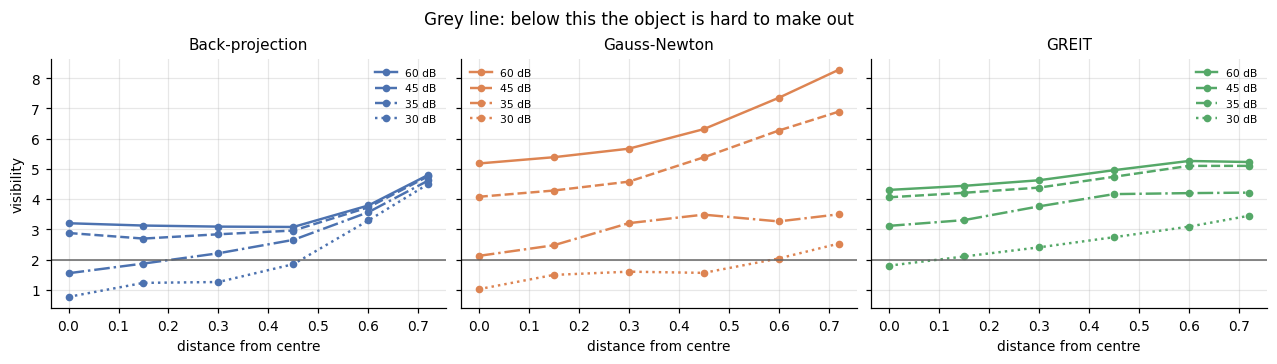

In [6]:
noise_levels = [60, 45, 35, 30]

survival_rows = []
for distance in distances:
    background_voltages, object_voltages, truth = all_data[distance]
    for method in eit.METHODS:
        solver, setup_seconds = prepared[method]
        for noise_db in noise_levels:
            visibility_scores = []
            for repeat in range(5):
                generator = np.random.default_rng([eit.RANDOM_SEED, noise_db, repeat])
                noisy_background, noisy_object = eit.add_measurement_noise(
                    background_voltages, object_voltages, noise_db, generator)
                noisy_result = eit.reconstruct_image(
                    method, coarse_mesh, measurement_setup, noisy_object,
                    noisy_background, prepared_solver=solver)
                visibility_scores.append(
                    eit.contrast_to_noise(noisy_result.image, truth))
            survival_rows.append(dict(method=method, distance=distance,
                                      noise_db=noise_db,
                                      visibility=float(np.mean(visibility_scores))))
survival = pd.DataFrame(survival_rows)
survival.to_csv(tables / "03_noise.csv", index=False)

figure, axes = plt.subplots(1, 3, figsize=(11.5, 3.2), constrained_layout=True, sharey=True)
for axis, method in zip(axes, eit.METHODS):
    rows = survival[survival.method == method]
    for noise_db, line_style in zip(noise_levels, ["-", "--", "-.", ":"]):
        one_level = rows[rows.noise_db == noise_db].sort_values("distance")
        axis.plot(one_level.distance, one_level.visibility, ls=line_style, marker="o",
                  ms=4, lw=1.6, color=eit.METHOD_COLOURS[method], label=f"{noise_db} dB")
    axis.axhline(2.0, color="0.4", lw=1.0)
    axis.set_xlabel("distance from centre"); axis.set_title(eit.METHOD_NAMES[method])
    axis.grid(alpha=0.3); axis.legend(fontsize=7)
axes[0].set_ylabel("visibility")
figure.suptitle("Grey line: below this the object is hard to make out", fontsize=11)
figure.savefig(figures / "03_noise.png")
plt.show()

At 60 dB everything is fine everywhere. As the noise gets worse the left-hand end of each curve
drops below the line first — meaning a blind spot opens up in the middle of the tank and grows
outward, while objects near the edge are still perfectly visible.

---

## What I took away from this notebook

- The middle of the tank is far less visible than the edge, and that single fact drives everything
  else here.
- Objects near the edge give a much bigger signal, come out sharper, and are easier to place
  accurately.
- Objects in the middle come out as large faint blobs and are the first thing lost when noise
  appears.
- No method gets the size right at any position — even at its best the blob is well above the real
  object size.
- So quoting one "resolution" number for an EIT system is misleading. It depends on where in the
  tank you are looking.

**Next:** [04 — more than one object](04_number_of_objects.ipynb)